In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 107.0 MB/s eta 0:00:0000:01:01


In [2]:
import pandas as pd
import numpy as np
from pulp import *

data = {
    'hour': np.arange(24),
    'energy_price': [20, 18, 15, 14, 15, 22, 45, 80, 75, 60, 55, 50, 48, 52, 65, 90, 110, 120, 100, 85, 70, 50, 40, 30], # $/MWh
    'demand': [10, 8, 7, 7, 8, 12, 25, 40, 35, 30, 28, 25, 24, 26, 30, 45, 55, 60, 50, 40, 30, 20, 15, 12] # MW
}
df = pd.DataFrame(data)

storage_capacity = 100  
max_charge_rate = 20    
max_discharge_rate = 20 
efficiency = 0.9        
initial_soc = 20        

model = LpProblem("Energy_Storage_Optimization", LpMinimize)

charge = LpVariable.dicts("Charge", df.index, lowBound=0, upBound=max_charge_rate)
discharge = LpVariable.dicts("Discharge", df.index, lowBound=0, upBound=max_discharge_rate)
soc = LpVariable.dicts("SOC", df.index, lowBound=0, upBound=storage_capacity) 

model += lpSum([(df.loc[i, 'energy_price'] * (charge[i] - discharge[i])) for i in df.index])

for i in df.index:

    if i == 0:
        model += soc[i] == initial_soc + (charge[i] * efficiency) - (discharge[i] / efficiency)
    else:
        model += soc[i] == soc[i-1] + (charge[i] * efficiency) - (discharge[i] / efficiency)

model.solve()

df['Optimized_Charge'] = [charge[i].varValue for i in df.index]
df['Optimized_Discharge'] = [discharge[i].varValue for i in df.index]
df['State_of_Charge'] = [soc[i].varValue for i in df.index]

print(f"Statü: {LpStatus[model.status]}")
print(df[['hour', 'energy_price', 'Optimized_Charge', 'Optimized_Discharge', 'State_of_Charge']].head())

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /usr/local/lib/python3.11/dist-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/0c6dacb93afd442f86448e0f5dc637c2-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/0c6dacb93afd442f86448e0f5dc637c2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 29 COLUMNS
At line 173 RHS
At line 198 BOUNDS
At line 271 ENDATA
Problem MODEL has 24 rows, 72 columns and 95 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 24 (0) rows, 71 (-1) columns and 94 (-1) elements
0  Obj 0 Primal inf 19.999999 (1) Dual inf 1329 (24)
28  Obj -8484.321
Optimal - objective value -8484.321
After Postsolve, objective -8484.321, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective -8484.320988 - 28 iterations time 0.002, Presolve 0.00
Option for printingOptions changed from normal to all
Total time (CPU seconds):   

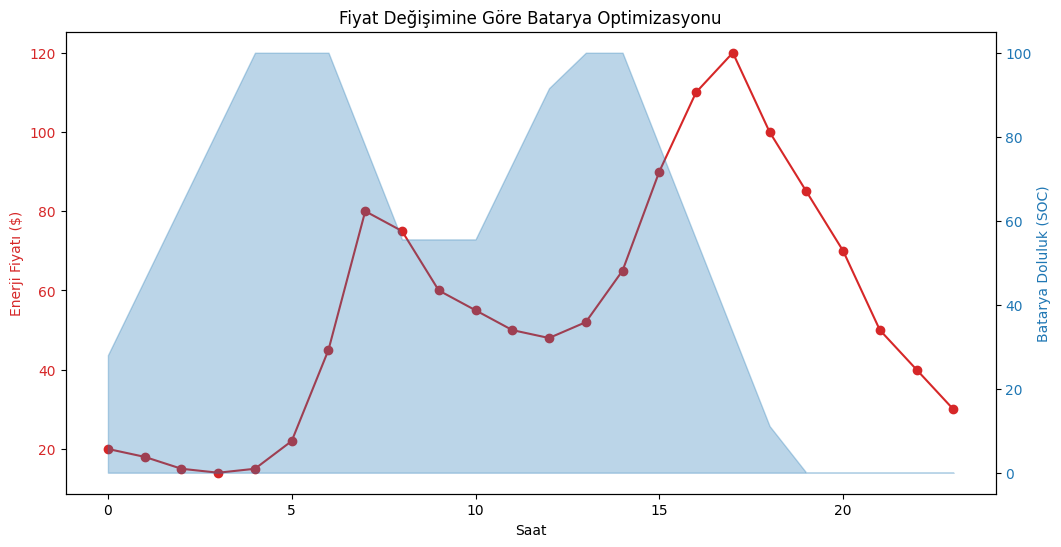

In [3]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Saat')
ax1.set_ylabel('Enerji Fiyatı ($)', color='tab:red')
ax1.plot(df['hour'], df['energy_price'], color='tab:red', marker='o', label='Fiyat')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Batarya Doluluk (SOC)', color='tab:blue')
ax2.fill_between(df['hour'], df['State_of_Charge'], color='tab:blue', alpha=0.3, label='SOC')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Fiyat Değişimine Göre Batarya Optimizasyonu')
plt.show()

Optimizasyon Tamamlandı. İlk 5 Saat:
   hour  energy_price  Optimal_Action  State_of_Charge
0     0            20       15.319582        33.787624
1     1            18       15.128509        47.403282
2     2            15       18.265684        63.842397
3     3            14       23.064210        81.842397
4     4            15       21.938670        99.842397


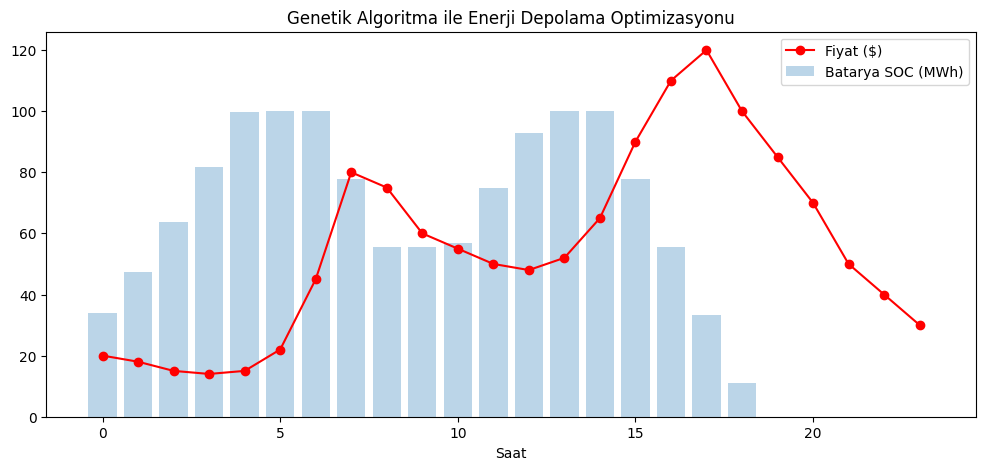

In [4]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

data = {
    'hour': np.arange(24),
    'energy_price': [20, 18, 15, 14, 15, 22, 45, 80, 75, 60, 55, 50, 48, 52, 65, 90, 110, 120, 100, 85, 70, 50, 40, 30]
}
df = pd.DataFrame(data)

CAPACITY = 100    
MAX_RATE = 20     
EFFICIENCY = 0.9  
INIT_SOC = 20     

def calculate_fitness(chromosome):
    """Kromozom: 24 saatlik şarj/deşarj kararları listesi (-20 ile +20 arası)"""
    current_soc = INIT_SOC
    total_cost = 0
    
    for i, action in enumerate(chromosome):
        if action > 0:
            actual_charge = min(action, MAX_RATE, (CAPACITY - current_soc) / EFFICIENCY)
            current_soc += actual_charge * EFFICIENCY
            total_cost += actual_charge * df.loc[i, 'energy_price']
        else: 
            actual_discharge = min(abs(action), MAX_RATE, current_soc * EFFICIENCY)
            current_soc -= actual_discharge / EFFICIENCY
            total_cost -= actual_discharge * df.loc[i, 'energy_price']
            
    return total_cost 

def run_genetic_algorithm(pop_size=100, generations=200):

    population = [np.random.uniform(-MAX_RATE, MAX_RATE, 24) for _ in range(pop_size)]
    
    for gen in range(generations):
        population = sorted(population, key=lambda x: calculate_fitness(x))

        new_generation = population[:int(pop_size * 0.1)]

        while len(new_generation) < pop_size:
            parent1, parent2 = random.sample(population[:20], 2)

            point = random.randint(1, 23)
            child = np.concatenate([parent1[:point], parent2[point:]])

            if random.random() < 0.2:
                child[random.randint(0, 23)] += np.random.uniform(-5, 5)
            
            new_generation.append(child)
            
        population = new_generation
    
    return population[0] 

best_strategy = run_genetic_algorithm()
df['Optimal_Action'] = best_strategy

soc_values = []
curr = INIT_SOC
for a in best_strategy:
    if a > 0: curr += min(a, MAX_RATE, (CAPACITY - curr) / EFFICIENCY) * EFFICIENCY
    else: curr -= min(abs(a), MAX_RATE, curr * EFFICIENCY) / EFFICIENCY
    soc_values.append(curr)
df['State_of_Charge'] = soc_values

print("Optimizasyon Tamamlandı. İlk 5 Saat:")
print(df.head())

plt.figure(figsize=(12,5))
plt.plot(df['hour'], df['energy_price'], label='Fiyat ($)', color='red', marker='o')
plt.bar(df['hour'], df['State_of_Charge'], alpha=0.3, label='Batarya SOC (MWh)')
plt.legend()
plt.title("Genetik Algoritma ile Enerji Depolama Optimizasyonu")
plt.xlabel("Saat")
plt.show()

In [5]:
initial_cost = sum(df['energy_price'] * 0)
optimized_cost = calculate_fitness(best_strategy)

print(f"Başlangıç Durumu Maliyeti: 0 $")
print(f"GA Sonrası Operasyonel Maliyet/Kar: {optimized_cost:.2f} $")
if optimized_cost < 0:
    print(f"Toplam Kar: {abs(optimized_cost):.2f} $")

Başlangıç Durumu Maliyeti: 0 $
GA Sonrası Operasyonel Maliyet/Kar: -8461.26 $
Toplam Kar: 8461.26 $


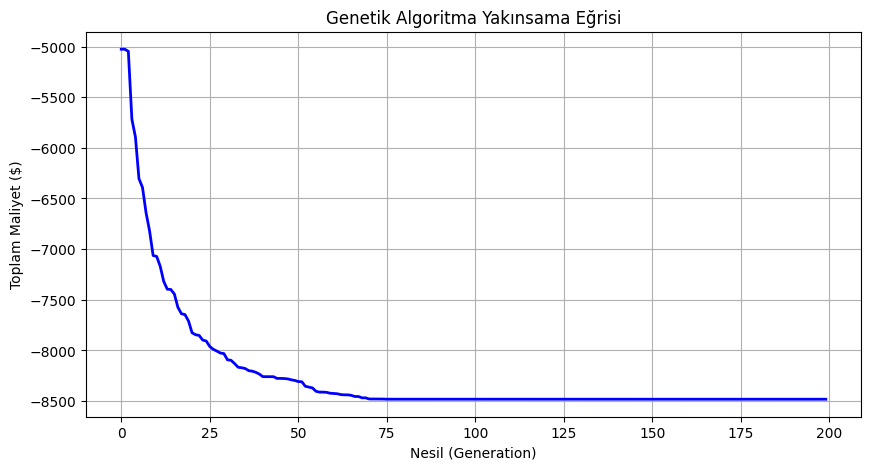

In [7]:
def run_genetic_algorithm(pop_size=100, generations=200):

    fitness_history = []
    
    population = [np.random.uniform(-MAX_RATE, MAX_RATE, 24) for _ in range(pop_size)]
    
    for gen in range(generations):

        population = sorted(population, key=lambda x: calculate_fitness(x))

        current_best_fitness = calculate_fitness(population[0])
        fitness_history.append(current_best_fitness)

        new_generation = population[:int(pop_size * 0.1)]
        while len(new_generation) < pop_size:
            parent1, parent2 = random.sample(population[:20], 2)
            point = random.randint(1, 23)
            child = np.concatenate([parent1[:point], parent2[point:]])
            if random.random() < 0.2:
                child[random.randint(0, 23)] += np.random.uniform(-5, 5)
            new_generation.append(child)
        population = new_generation

    return population[0], fitness_history

best_strategy, history = run_genetic_algorithm()

plt.figure(figsize=(10, 5))
plt.plot(history, color='blue', linewidth=2)
plt.title("Genetik Algoritma Yakınsama Eğrisi")
plt.xlabel("Nesil (Generation)")
plt.ylabel("Toplam Maliyet ($)")
plt.grid(True)
plt.show()